In [1]:
from google.colab import drive
try:
  drive.mount('/content/drive')
  print("Kết nối thành công với gg drive")
except Exception as e:
  print(f"Đã xảy ra lỗi: {e}")

Mounted at /content/drive
Kết nối thành công với gg drive


-----------------------------------------------------------------
METRIC               | LSB-Based    | Phase Coding | Improved LSB
-----------------------------------------------------------------
MSE                  | 0.000000     | 0.001925     | 0.032562
PSNR (dB)            | 106.7603       | 40.1723       | 106.7701
SNR (dB)             | 82.9233       | 17.8368       | 82.9399
Avg. Time (s)        | 1.8267       | 3.0719       | 1.7033
-----------------------------------------------------------------


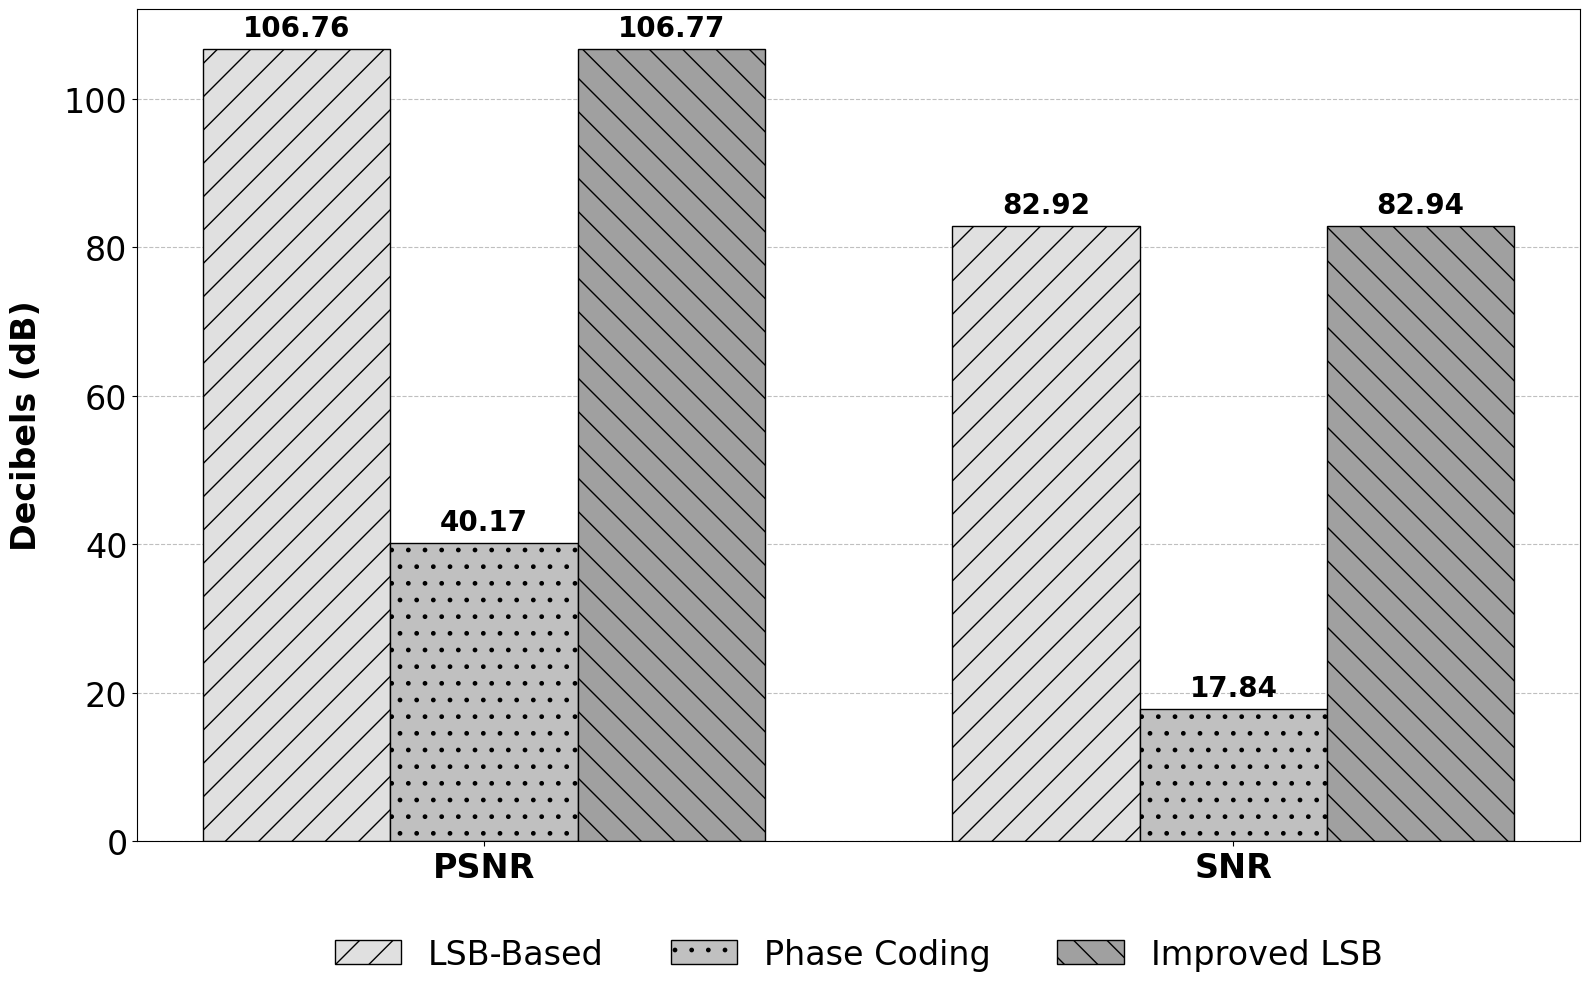

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

files_map = {
    '/content/drive/MyDrive/Git-audio-stego/audio-steganograph/AudioStego/exp/logs/benchmark_local_input_1_NoRandom_20260201_040937.csv': 'LSB-Based',
    '/content/drive/MyDrive/Git-audio-stego/audio-steganograph/AudioStego/exp/logs/benchmark_local_input_7_PhaseCoding_full_20260129_092309.csv': 'Phase Coding',
    '/content/drive/MyDrive/Git-audio-stego/audio-steganograph/AudioStego/exp/AudioStego/logs_5cases_musdb/5_Random_Adaptive_ContentSalt/benchmark.csv': 'Improved LSB'
}

results = {}

for filename, method_name in files_map.items():
    if not os.path.exists(filename):
        continue
    try:
        try:
            df = pd.read_csv(filename, sep='\t')
            if len(df.columns) < 2: raise ValueError
        except:
            df = pd.read_csv(filename, sep=',')

        df.columns = df.columns.str.strip()
        df_clean = df.iloc[:-1].copy()

        cols = ['MSE', 'PSNR', 'SNR', 'Time(s)']
        for col in cols:
            if col in df_clean.columns:
                df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

        avg_mse = df_clean['MSE'].mean() if 'MSE' in df_clean.columns else 0.0
        avg_psnr = df_clean['PSNR'].mean() if 'PSNR' in df_clean.columns else 0.0
        avg_snr = df_clean['SNR'].mean() if 'SNR' in df_clean.columns else 0.0
        avg_time = df_clean['Time(s)'].mean() if 'Time(s)' in df_clean.columns else 0.0

        results[method_name] = {
            'MSE': avg_mse,
            'PSNR (dB)': avg_psnr,
            'SNR (dB)': avg_snr,
            'Avg. Time (s)': avg_time
        }

    except Exception:
        pass

if results:
    print("-" * 65)
    print(f"{'METRIC':<20} | {'LSB-Based':<12} | {'Phase Coding':<12} | {'Improved LSB':<12}")
    print("-" * 65)

    metrics_order = ['MSE', 'PSNR (dB)', 'SNR (dB)', 'Avg. Time (s)']
    for m in metrics_order:
        v1 = results.get('LSB-Based', {}).get(m, 0.0)
        v2 = results.get('Phase Coding', {}).get(m, 0.0)
        v3 = results.get('Improved LSB', {}).get(m, 0.0)

        if m == 'MSE':
            print(f"{m:<20} | {v1:.6f}     | {v2:.6f}     | {v3:.6f}")
        else:
            print(f"{m:<20} | {v1:.4f}       | {v2:.4f}       | {v3:.4f}")
    print("-" * 65)

    methods = list(results.keys())
    plot_metrics = ['PSNR (dB)', 'SNR (dB)']

    x = np.arange(len(plot_metrics))
    width = 0.25

    fig, ax = plt.subplots(figsize=(16, 10))

    colors = ['#e0e0e0', '#c0c0c0', '#a0a0a0']
    patterns = ['/', '.', '\\']

    for i, method in enumerate(methods):
        vals = [results[method][m] for m in plot_metrics]
        rects = ax.bar(x + (i - 1) * width, vals, width, label=method,
                       color=colors[i], edgecolor='black', hatch=patterns[i])

        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5), textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=20, fontweight='bold', color='black')

    FONT_SIZE = 24
    FONT_WEIGHT = 'bold'

    ax.set_ylabel('Decibels (dB)', fontsize=FONT_SIZE, fontweight=FONT_WEIGHT, labelpad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(['PSNR', 'SNR'], fontsize=FONT_SIZE, fontweight=FONT_WEIGHT)
    ax.tick_params(axis='y', labelsize=FONT_SIZE)

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')

    ax.legend(fontsize=FONT_SIZE, loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)

    plt.tight_layout()
    plt.savefig('Chart_Final_Clean.png', dpi=300)
    plt.show()
else:
    print("No data found.")

--- ĐANG XỬ LÝ DỮ LIỆU ---
 [OK] LSB-Based
 [OK] Phase Coding
 [OK] Improved LSB

 BẢNG TỔNG HỢP KẾT QUẢ TRUNG BÌNH
                 PSNR     SNR
LSB-Based    106.7603 82.9233
Phase Coding  40.1723 17.8368
Improved LSB 106.7701 82.9399



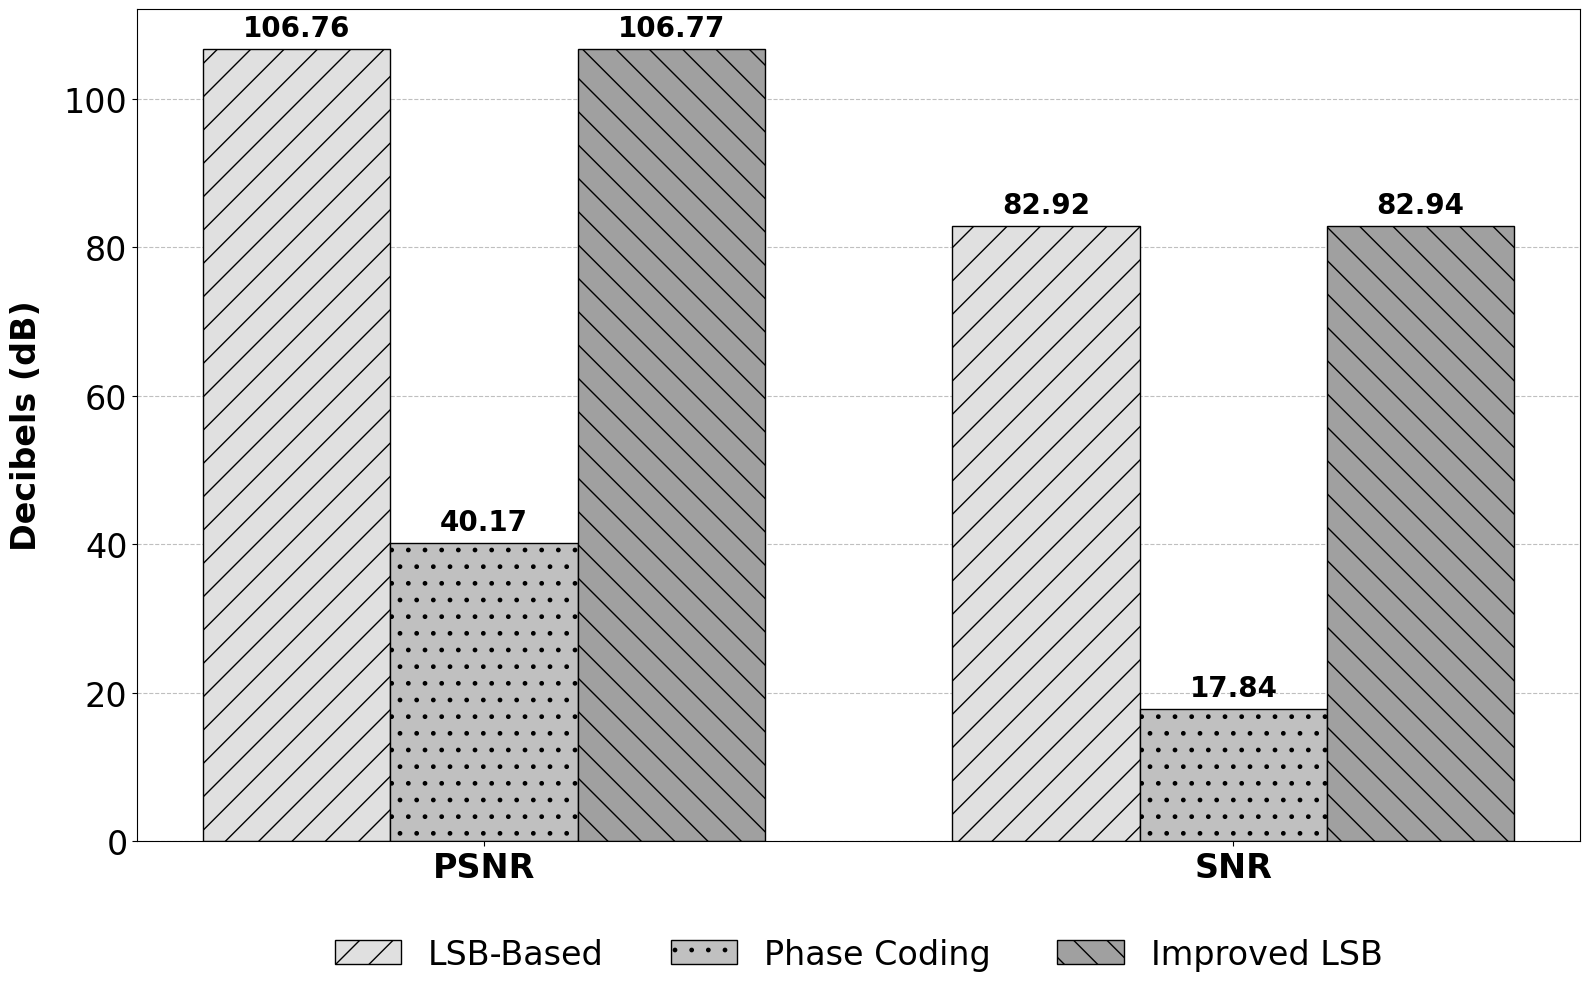


[ĐÃ LƯU] Biểu đồ đã lưu tại: Chart_Combined_OldStyle_WithText.png


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ======================================================
# 1. CẤU HÌNH ĐƯỜNG DẪN FILE
# ======================================================
files_map = {
    '/content/drive/MyDrive/Git-audio-stego/audio-steganograph/AudioStego/exp/logs/benchmark_local_input_1_NoRandom_20260201_040937.csv': 'LSB-Based',
    '/content/drive/MyDrive/Git-audio-stego/audio-steganograph/AudioStego/exp/logs/benchmark_local_input_7_PhaseCoding_full_20260129_092309.csv': 'Phase Coding',
    '/content/drive/MyDrive/Git-audio-stego/audio-steganograph/AudioStego/exp/AudioStego/logs_5cases_musdb/5_Random_Adaptive_ContentSalt/benchmark.csv': 'Improved LSB'
}

results = {}

print("--- ĐANG XỬ LÝ DỮ LIỆU ---")

for filename, method_name in files_map.items():
    if not os.path.exists(filename):
        print(f" [!] Không tìm thấy: {filename}")
        continue
    try:
        try:
            df = pd.read_csv(filename, sep='\t')
            if len(df.columns) < 2: raise ValueError
        except:
            df = pd.read_csv(filename, sep=',')

        df.columns = df.columns.str.strip()
        df_clean = df.iloc[:-1].copy()

        # Chuyển đổi sang số
        for col in ['PSNR', 'SNR']:
            if col in df_clean.columns:
                df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

        # Tính trung bình
        avg_psnr = df_clean['PSNR'].mean() if 'PSNR' in df_clean.columns else 0.0
        avg_snr = df_clean['SNR'].mean() if 'SNR' in df_clean.columns else 0.0

        results[method_name] = {'PSNR': avg_psnr, 'SNR': avg_snr}
        print(f" [OK] {method_name}")

    except Exception as e:
        print(f" [Err] {method_name}: {e}")

# ======================================================
# [MỚI THÊM] IN KẾT QUẢ DẠNG TEXT/BẢNG
# ======================================================
if results:
    print("\n" + "="*45)
    print(" BẢNG TỔNG HỢP KẾT QUẢ TRUNG BÌNH")
    print("="*45)

    # Tạo DataFrame để in bảng cho đẹp
    summary_df = pd.DataFrame(results).T  # Chuyển vị (Dòng là Method, Cột là Metric)

    # Định dạng in số (lấy 4 số lẻ)
    print(summary_df.to_string(float_format="{:.4f}".format))
    print("="*45 + "\n")
else:
    print("Không có dữ liệu để hiển thị.")

# ======================================================
# 2. VẼ BIỂU ĐỒ (STYLE CŨ: HATCHING + GRAYSCALE + FONT 24)
# ======================================================
if results:
    methods = list(results.keys())
    metrics = ['PSNR', 'SNR']

    # Tạo dữ liệu vẽ
    x = np.arange(len(metrics))
    width = 0.25

    # Tăng kích thước ảnh
    fig, ax = plt.subplots(figsize=(16, 10))

    # --- STYLE CỦA BẠN ---
    # Màu xám/bạc
    colors = ['#e0e0e0', '#c0c0c0', '#a0a0a0']
    # Họa tiết (Gạch chéo, Chấm, Gạch ngược)
    patterns = ['/', '.', '\\']

    # Vẽ lần lượt 3 cột
    # Cột 1
    rects1 = ax.bar(x - width, [results[methods[0]]['PSNR'], results[methods[0]]['SNR']], width,
                    label=methods[0], color=colors[0], edgecolor='black', hatch=patterns[0])

    # Cột 2
    rects2 = ax.bar(x, [results[methods[1]]['PSNR'], results[methods[1]]['SNR']], width,
                    label=methods[1], color=colors[1], edgecolor='black', hatch=patterns[1])

    # Cột 3
    rects3 = ax.bar(x + width, [results[methods[2]]['PSNR'], results[methods[2]]['SNR']], width,
                    label=methods[2], color=colors[2], edgecolor='black', hatch=patterns[2])

    # --- CẤU HÌNH FONT SIZE 24 ---
    FONT_SIZE = 24
    FONT_WEIGHT = 'bold'

    ax.set_ylabel('Decibels (dB)', fontsize=FONT_SIZE, fontweight=FONT_WEIGHT, labelpad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=FONT_SIZE, fontweight=FONT_WEIGHT)
    ax.tick_params(axis='y', labelsize=FONT_SIZE)

    # Lưới ngang mờ
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')

    # Legend
    ax.legend(fontsize=FONT_SIZE, loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)

    # Hiển thị số trên đầu cột
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=20, fontweight='bold', color='black')

    autolabel(rects1)
    autolabel(rects2)
    autolabel(rects3)

    plt.tight_layout()
    plt.savefig('Chart_Combined_OldStyle_WithText.png', dpi=300)
    plt.show()
    print("\n[ĐÃ LƯU] Biểu đồ đã lưu tại: Chart_Combined_OldStyle_WithText.png")

else:
    print("Không có dữ liệu để vẽ.")

--- ĐANG ĐỌC DỮ LIỆU ---
 [OK] LSB-Based
 [OK] Phase Coding
 [OK] Improved LSB

METRIC          | LSB-Based    | Phase Coding | Improved LSB
Accuracy        | 0.6867       | 0.8720       | 0.6544
Precision       | 0.7414       | 0.9936       | 0.6262
Recall          | 0.6467       | 0.7386       | 0.7911
F1-Score        | 0.6644       | 0.8473       | 0.6936



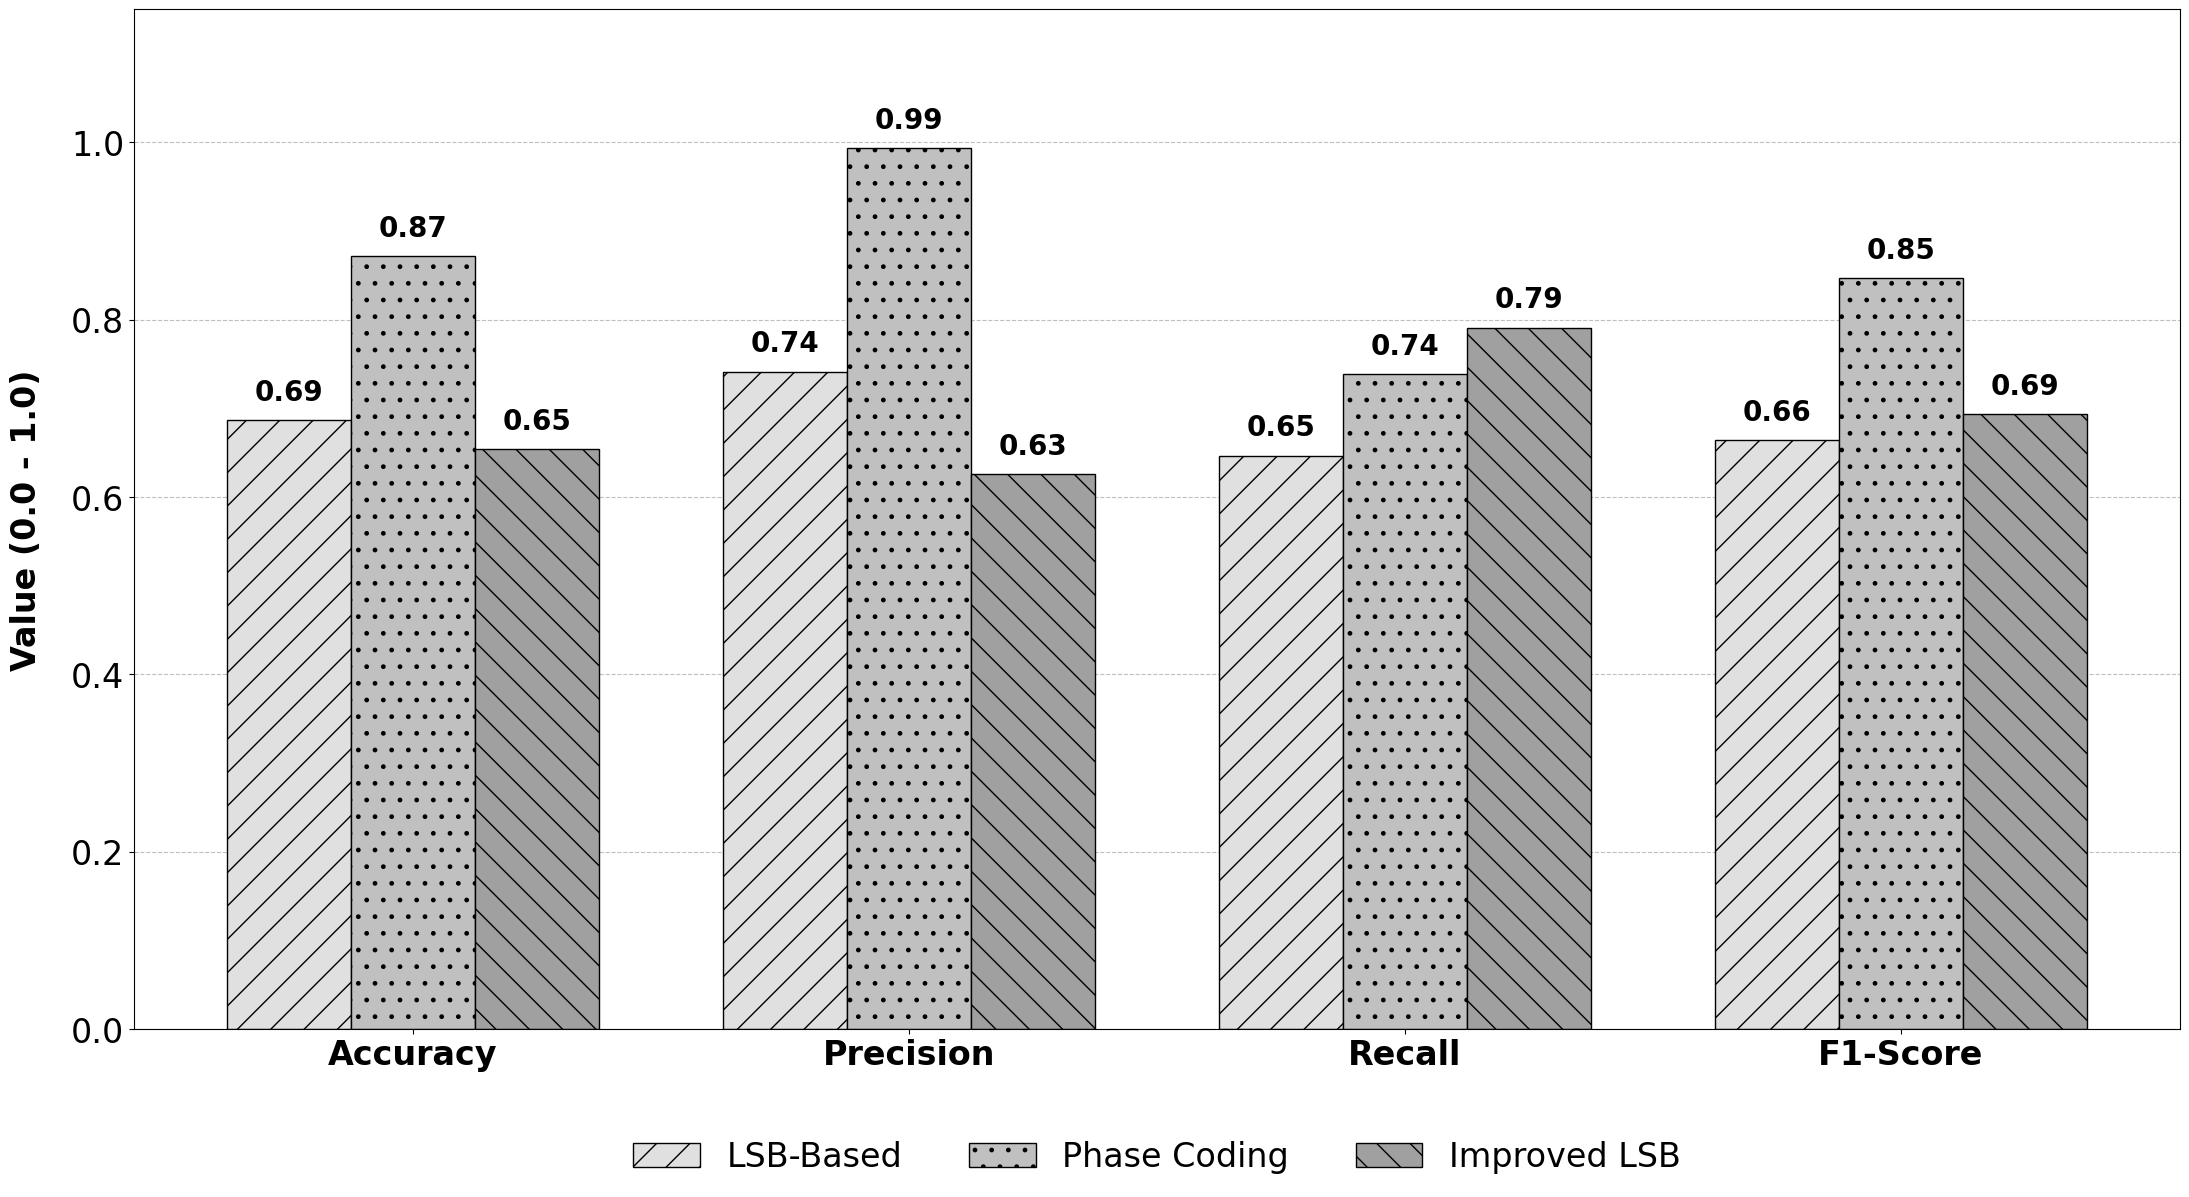

[HOÀN TẤT] Biểu đồ đã lưu tại: Chart_CNN_Performance_OldStyle.png


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Paste đường dẫn file của bạn vào đây
path_lsb = '/content/drive/MyDrive/Git-audio-stego/audio-steganograph/Steganalysis/logs/MUSDB_LSB/Summary_CNN_D5_F64_LR0.0001_BATCH32_20260128_232005.csv'
path_phase = '/content/drive/MyDrive/Git-audio-stego/audio-steganograph/Steganalysis/logs/MUSDB_Phase_CNN/Summary_CNN_20260130_204302.csv'
path_improved = '/content/drive/MyDrive/Git-audio-stego/audio-steganograph/Steganalysis/logs/MUSDB_LSB_5_Random_Adaptive_ContentSalt/Summary_CNN_20260129_112045.csv'

files_map = {
    'LSB-Based': path_lsb,
    'Phase Coding': path_phase,
    'Improved LSB': path_improved
}

# Mapping tên cột trong CSV -> Tên hiển thị
metrics_mapping = {
    'Val_Acc': 'Accuracy',
    'Precision': 'Precision',
    'Recall': 'Recall',
    'F1': 'F1-Score'
}


results = {}

print("--- ĐANG ĐỌC DỮ LIỆU ---")

for method_name, filepath in files_map.items():
    if not os.path.exists(filepath):
        print(f" [!] Bỏ qua (Không tìm thấy): {method_name}")
        continue

    try:
        df = pd.read_csv(filepath)
        df.columns = df.columns.str.strip()

        # Dictionary lưu chỉ số của phương pháp này
        method_metrics = {}

        for raw_metric, display_name in metrics_mapping.items():
            # Tìm dòng chứa Metric
            row = df[df['Metric'].astype(str).str.contains(raw_metric, case=False, na=False)]
            if not row.empty:
                val = row['Mean'].values[0]
                method_metrics[display_name] = val
            else:
                method_metrics[display_name] = 0.0

        results[method_name] = method_metrics
        print(f" [OK] {method_name}")

    except Exception as e:
        print(f" [ERR] {method_name}: {e}")


if results:
    print("\n" + "="*60)
    print(f"{'METRIC':<15} | {'LSB-Based':<12} | {'Phase Coding':<12} | {'Improved LSB':<12}")
    print("="*60)

    # Duyệt qua từng chỉ số để in dòng
    display_metrics = list(metrics_mapping.values()) # ['Accuracy', 'Precision', ...]

    for m in display_metrics:
        v1 = results.get('LSB-Based', {}).get(m, 0.0)
        v2 = results.get('Phase Coding', {}).get(m, 0.0)
        v3 = results.get('Improved LSB', {}).get(m, 0.0)
        print(f"{m:<15} | {v1:.4f}       | {v2:.4f}       | {v3:.4f}")
    print("="*60 + "\n")

if results:
    labels = list(metrics_mapping.values())
    x = np.arange(len(labels))
    width = 0.25

    # Tăng kích thước hình để chứa font to
    fig, ax = plt.subplots(figsize=(22, 12))

    # --- STYLE GRAYSCALE + HATCHING ---
    colors = ['#e0e0e0', '#c0c0c0', '#a0a0a0'] # Xám nhạt -> Đậm dần
    patterns = ['/', '.', '\\']                # Gạch chéo, Chấm, Gạch ngược

    draw_order = ['LSB-Based', 'Phase Coding', 'Improved LSB']

    for i, method in enumerate(draw_order):
        if method in results:
            # Lấy list giá trị theo đúng thứ tự nhãn
            vals = [results[method][label] for label in labels]

            # Vẽ cột
            rects = ax.bar(x + (i - 1) * width, vals, width, label=method,
                           color=colors[i], edgecolor='black', hatch=patterns[i])

            # Hiển thị số trên cột (Font 20)
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.2f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 10), textcoords="offset points",
                            ha='center', va='bottom',
                            fontsize=20, fontweight='bold', color='black')

    # --- CẤU HÌNH FONT SIZE 24 ---
    FONT_SIZE = 24
    FONT_WEIGHT = 'bold'

    ax.set_ylabel('Value (0.0 - 1.0)', fontsize=FONT_SIZE, fontweight=FONT_WEIGHT, labelpad=20)

    # Nếu muốn hiện tiêu đề thì bỏ comment dòng dưới
    # ax.set_title('CNN Detection Performance', fontsize=28, fontweight=FONT_WEIGHT, pad=30)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=FONT_SIZE, fontweight=FONT_WEIGHT)
    ax.tick_params(axis='y', labelsize=FONT_SIZE)

    # Lưới ngang
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
    ax.set_ylim(0, 1.15) # Tăng chiều cao trục Y để số không bị cắt

    # Chú thích (Legend)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08),
              ncol=3, fontsize=FONT_SIZE, frameon=False)

    plt.tight_layout()
    output_filename = 'Chart_CNN_Performance_OldStyle.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[HOÀN TẤT] Biểu đồ đã lưu tại: {output_filename}")

else:
    print("[!] Không có dữ liệu để vẽ.")